In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import joblib

In [6]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
X = df[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [9]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

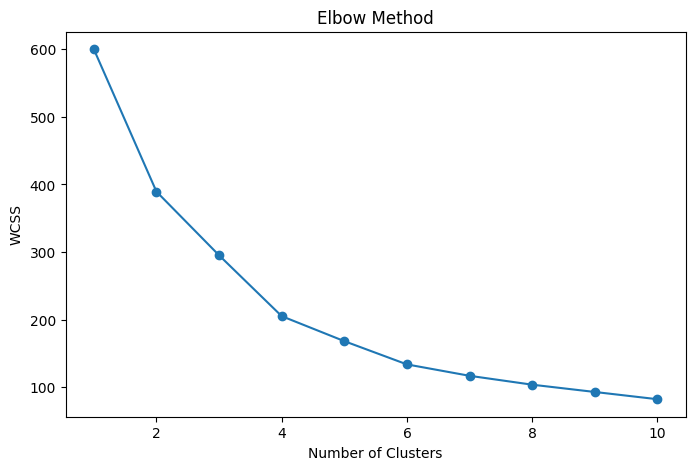

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")
plt.show()

In [11]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

clusters[:10]

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1], dtype=int32)

In [12]:
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [13]:
df["Cluster"].value_counts()

Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64

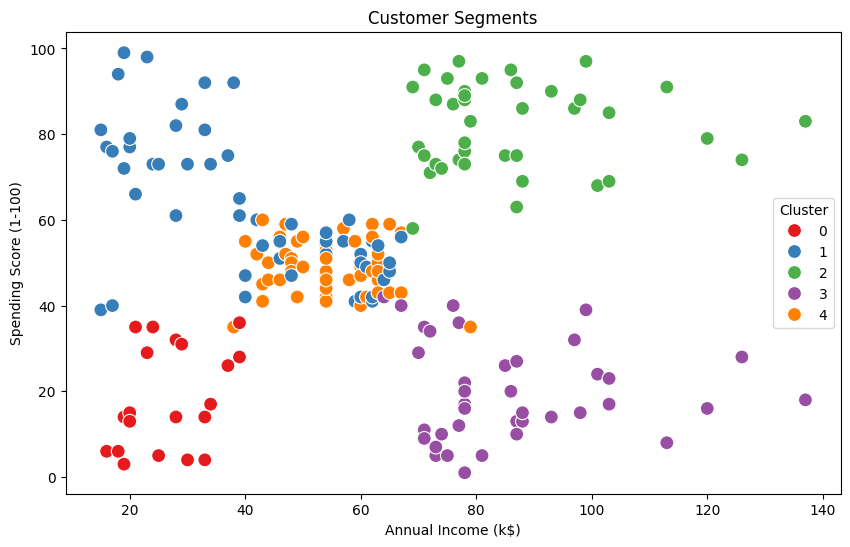

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="Set1",
    s=100
)

plt.title("Customer Segments")

plt.show()

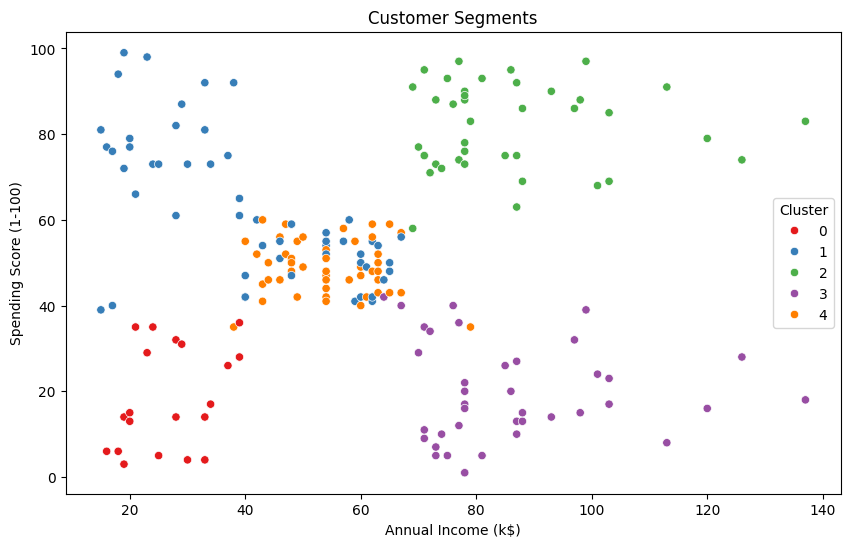

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("Customer Segments")

plt.savefig(
    "../static/images/cluster_plot.png"
)

plt.show()

In [16]:
cluster_summary = df.groupby(
    "Cluster"
).mean(numeric_only=True)

cluster_summary

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,24.100000,46.250000,26.750000,18.350000
1,55.648148,25.185185,41.092593,62.240741
2,161.025000,32.875000,86.100000,81.525000
3,159.743590,39.871795,86.102564,19.358974
4,83.872340,55.638298,54.382979,48.851064


In [17]:
segment_names = {
    0:"Premium Customers",
    1:"Budget Customers",
    2:"Young High Spenders",
    3:"Average Customers",
    4:"Careful Customers"
}

df["Segment"] = df["Cluster"].map(
    segment_names
)

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,Male,19,15,39,1,Budget Customers
1,2,Male,21,15,81,1,Budget Customers
2,3,Female,20,16,6,0,Premium Customers
3,4,Female,23,16,77,1,Budget Customers
4,5,Female,31,17,40,1,Budget Customers


In [18]:
joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [19]:
df.to_csv(
    "../data/processed_data.csv",
    index=False
)